Creating Dot Job Maps - Where are the jobs?

In [ ]:
!python -m pip install git+https://github.com/walkerke/pygris.git

In [1]:
from arcgis.gis import GIS
from arcgis.features import FeatureLayer

In [2]:
import sys
from shapely import geometry
from shapely.wkb import loads
from shapely.geometry import Point
from shapely.geometry import Polygon
from shapely import wkt
from random import uniform, shuffle
import pandas as pd
import geopandas as gpd
import geoplot as gplt
import os
import numpy as np
from pygris.data import get_lodes
import pydeck
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pygris.geocode import geocode

In [5]:
dirpath = (r'C:\GreenGIS\Job-Dot-Maps')
os.chdir(dirpath)

**Let's test for Richmond!**\
Data Dictionary of LODES WAC:

In [ ]:
#   CNS01 NAICSsector11AgricultureForestryFishingAndHunting
#   CNS02 NAICSsector21MiningQuarryingAndOilAndGasExtraction
#   CNS03 NAICSsector22Utilities
#   CNS04 NAICSsector23Construction
#   CNS05 NAICSsector31to33Manufactoring
#   CNS06 NAICSsector42WholesaleTrade
#   CNS07 NAICSsector44to45RetailTrade
#   CNS08 NAICSsector48to49TransportationAndWarehousing
#   CNS09 NAICSsector51Information
#   CNS10 NAICSsector52FinanceAndInsurance
#   CNS11 NAICSsector53RealEstateAndRentalAndLeasing
#   CNS12 NAICSsector54ProfessionalScientificAndTechnicalServices
#   CNS13 NAICSsector55ManagementOfCompaniesAndEnterprises
#   CNS14 NAICSsector56AdministrativeAndSupportAndWasteManagementAndRemediationServices
#   CNS15 NAICSsector61EducationalServices
#   CNS16 NAICSsector62HealthCareAndSocialAssistance
#   CNS17 NAICSsector71ArtsEntertainmentAndRecreation
#   CNS18 NAICSsector72AccommodationAndFoodServices
#   CNS19 NAICSsector81OtherServicesExceptPublicAdministration
#   CNS20 NAICSsector92PublicAdministration

In [60]:
#We will use data from Richmond City's Parcel Mapper
#Geometry values are disabled likely for their security and so I cannot filter from the feature service
#Feature service information is listed below

# Define the URL of the feature layer
feature_service_url = "https://services1.arcgis.com/k3vhq11XkBNeeOfM/arcgis/rest/services/Parcels/FeatureServer/0"
# Create a FeatureLayer object
feature_layer = FeatureLayer(feature_service_url)
# Query the first 10 features
features = feature_layer.query(where="1=1", out_fields="*", return_geometry=True)
# Convert the features to a DataFrame
sdf = features.sdf
gdf = sdf

#I will ready the parcels from a copy on my desktop - 
#I will filter and edit the parcels in ArcGIS Pro but it would be done here like this:
gdf['LandUse'] = gdf['LandUse'].astype(str).str.strip()
# Define the values to be removed
values_to_keep = ['Commercial', 'Industrial', 'Mixed-Use', 'Institutional', 'Office', 'Government']

# Remove rows where 'LandUse' is in the list of values to remove 
gdf_filtered = gdf[gdf['LandUse'].isin(values_to_keep)]

# Drop rows where 'LandUse' is empty (NaN)
gdf_filtered = gdf_filtered.dropna(subset=['LandUse']) # Drop NaN strings after conversion

print(gdf['PropertyClass'].unique())

gdf['PropertyClass'] = gdf['PropertyClass'].astype(str).str.strip()
#Removing Air Space, Cemeteries, County Clubs, Parking Decks and Parking Lots, Railroads, Islands, Paved Parking, Parks
values_to_remove_PC = ['R Paved Plarking', 'R Garage/Outbuilding', 'B Air Space', 'B Parking Deck', 'B Paved Surface Parking', 'B Religious/Church/Synagogue', 'R Res/Comm Mixed Use']

# Remove rows where 'PropertyClassID' in is the list of values to remove
gdf_filtered2 = gdf[~gdf['PropertyClassID'].isin(values_to_remove_PC)]

# Ensure that gdf_filtered2 is a GeoDataFrame by assigning geometry
gdf_filtered2 = gpd.GeoDataFrame(gdf_filtered2, geometry=gdf.geometry)

# Display the filtered DataFrame and save as shapefile "jobparcels"

In [ ]:
#reading the block groups
block_groups = gpd.read_file(r'C:\GreenGIS\JobDot - Results\Census_Block_Group_2020.shp')

#assigning the parcels a block group
if jobparcels.crs != block_groups.crs:
    jobparcels = jobparcels.to_crs(block_groups.crs)

parcels_with_block_groups = gpd.sjoin(jobparcels, block_groups, how='left', op='within')
parcels_with_block_groups.to_file(r'C:\GreenGIS\JobDot\jobparcelsgroup.shp', driver='ESRI Shapefile')
parcels_with_block_groups.head()

In [29]:
#i had saved this as parcels_bg a different try - 
parcels_bg = gpd.read_file(r'C:\GreenGIS\JobDot - Results\Parcels_BlockGroup.shp')
parcels_bg.head()

,ParcelID,PIN,OwnerName,AsrLocatio,MailAddres,MailCity,MailState,MailZip,Assessment,LandValue,...,TotalValue,LandSqFt,ProvalAsmt,TaxExemptC,PropertyCl,Property_1,LandUse,Mailable,STFID,geometry
0,9161,C0051092004,P S M Parkway Llc,6620,8901 Brook Rd,Glen Allen,VA,23060,2025-01-01,262000.0,...,1237000.0,24956.0,471,NaN,461,B Motel,Commercial,1,517600710042,"POLYGON ((11767585.000 3708372.250, 11767680.0..."
1,382227,E0000039007,City Of Richmond Public Works,390,900 E Broad St Rm 701,Richmond,VA,23219,2025-01-01,1000.0,...,2000.0,7536.0,410,100,498,B Commercial Miscellaneous,Commercial,1,517600305022,"POLYGON ((11791300.539 3719708.522, 11791322.8..."
2,252547,S0080276009,2107 West Commerce Llc,2107,6014 St Andrews Lane,Richmond,VA,23226,2025-01-01,173000.0,...,236000.0,121271.0,480,NaN,509,B Industrial Shell,Industrial,1,517600608004,"POLYGON ((11792092.508 3704561.803, 11791948.8..."
3,252543,S0080276007,American Builders & Contractors Supply Co Inc,2114,One Abc Parkway,Beloit,WI,53511,2025-01-01,861000.0,...,934000.0,307446.0,480,NaN,533,B Storage Warehouse,Industrial,1,517600608004,"POLYGON ((11791320.430 3704298.464, 11791543.7..."
4,62983,S0090301027,Arias Darwin A,2613,4428 Stanley Dr,N Chesterfield,VA,23234,2025-01-01,47000.0,...,55000.0,6250.0,484,NaN,506,B Industrial Paved Parking,Industrial,0,517600609001,"POLYGON ((11789337.121 3694874.086, 11789348.3..."


In [51]:
#Now we need to separate by land use type and dissovle by the Census Block they are in 
Commercial_gdf = parcels_bg.loc[parcels_bg['LandUse'] == 'Commercial']
Government_gdf = parcels_bg.loc[parcels_bg['LandUse'] == 'Government']
Industrial_gdf = parcels_bg.loc[parcels_bg['LandUse'] == 'Industrial']
Institutional_gdf = parcels_bg.loc[parcels_bg['LandUse'] == 'Institutional']
Mixed_gdf = parcels_bg.loc[parcels_bg['LandUse'] == 'Mixed-Use']
Office_gdf = parcels_bg.loc[parcels_bg['LandUse'] == 'Office']


Commercial_gdf = Commercial_gdf.dissolve(by='STFID')
Government_gdf = Government_gdf.dissolve(by='STFID')
Industrial_gdf = Industrial_gdf.dissolve(by='STFID')
Institutional_gdf = Institutional_gdf.dissolve(by='STFID')
Mixed_gdf = Mixed_gdf.dissolve(by='STFID')
Office_gdf = Office_gdf.dissolve(by='STFID')

#now we will get the WAC data setup and join these after

In [ ]:
#I tested first with goverment alone
Government_gdf.head()

In [52]:

Commercial_gdf.to_file("Commercial.shp")
Government_gdf.to_file("Government.shp")
Industrial_gdf.to_file("Industrial.shp")
Institutional_gdf.to_file("Institutional.shp")
Mixed_gdf.to_file("Mixed.shp")
Office_gdf.to_file("Office.shp")

#### TESTING OTHER WAC WACKY METHOD - Using **PYGRIS**

In [6]:
va_lodes_wac = get_lodes(
  state = "VA", 
  year = 2021, 
  lodes_type = "wac",
  # cache = True,
  return_geometry = True,
  agg_level = "block"
)


Requesting feature geometry.
Using FIPS code '51' for input 'va'


KeyboardInterrupt: 

In [14]:
va_lodes_wac.head()

,w_geocode,geometry,index,C000,CA01,CA02,CA03,CE01,CE02,CE03,...,CFA01,CFA02,CFA03,CFA04,CFA05,CFS01,CFS02,CFS03,CFS04,CFS05
0,510650201011027,"POLYGON ((-78.27375 37.87051, -78.27324 37.870...",13141,780,60,445,275,136,197,447,...,0,0,0,0,0,0,0,0,0,0
1,517700029002005,"POLYGON ((-79.96631 37.21992, -79.96620 37.219...",44538,58,22,27,9,20,27,11,...,0,0,0,0,0,0,0,0,0,0
2,517700025012069,"POLYGON ((-79.95938 37.28111, -79.95924 37.281...",44408,2,1,1,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
3,511870204003011,"POLYGON ((-78.21074 38.93709, -78.21039 38.937...",31785,4,1,2,1,0,1,3,...,0,0,0,0,0,0,0,0,0,0
4,517700029003000,"POLYGON ((-79.95633 37.24925, -79.95613 37.249...",44540,17,3,4,10,6,6,5,...,0,0,0,0,0,0,0,0,0,0


In [15]:
#creating groups of jobs that match the major land values
va_lodes_wac['Comm'] = va_lodes_wac['CNS06'] + va_lodes_wac['CNS07'] + va_lodes_wac['CNS18']
va_lodes_wac['Gov'] = va_lodes_wac['CNS20']
va_lodes_wac['Ind'] = va_lodes_wac['CNS01'] + va_lodes_wac['CNS02'] + va_lodes_wac['CNS03'] + va_lodes_wac['CNS04'] + va_lodes_wac['CNS05'] + va_lodes_wac['CNS08'] + va_lodes_wac['CNS14']
va_lodes_wac['Inst'] = va_lodes_wac['CNS15'] + va_lodes_wac['CNS16']
va_lodes_wac['MU'] = va_lodes_wac['CNS17'] + va_lodes_wac['CNS19']
va_lodes_wac['Off'] = va_lodes_wac['CNS09'] + va_lodes_wac['CNS10'] + va_lodes_wac['CNS11'] + va_lodes_wac['CNS12'] + va_lodes_wac['CNS13']

#overwriting the csv
va_lodes_wac.to_csv('va_lodes_wac.csv')

**LODES 8 is enumerated with 2020 Census Blocks.**

In [16]:
#Ensure that the geocode is a string and make a FIPS code 
va_lodes_wac['w_geocode'] = va_lodes_wac['w_geocode'].astype(str)
va_lodes_wac['City'] = va_lodes_wac['w_geocode'].str[0:5].astype(str)
#WAC_2021['BG'] = WAC_2021['w_geocode'].str[0:12].astype(str)

#We are going to test with Richmond City so let's just get the 51760 FIPS
#all counties would include these - '51036', '51041', '51075', '51085', '51087', '51127', '51145'
city_list = ['51760']
rva_lodes_wac = va_lodes_wac[va_lodes_wac['City'].isin(city_list)]

#writing the csv
rva_lodes_wac.to_csv('rva_lodes_wac.csv')
rva_lodes_wac.head()

,w_geocode,geometry,index,C000,CA01,CA02,CA03,CE01,CE02,CE03,...,CFS03,CFS04,CFS05,Comm,Gov,Ind,Inst,MU,Off,City
209,517600206001009,"POLYGON ((-77.41517 37.53244, -77.41467 37.532...",42358,3,1,2,0,0,3,0,...,0,0,0,0,0,3,0,0,0,51760
211,517600402022062,"POLYGON ((-77.46061 37.55681, -77.46058 37.556...",42723,11,2,6,3,2,9,0,...,0,0,0,11,0,0,0,0,0,51760
347,517600610023018,"POLYGON ((-77.44171 37.52524, -77.44143 37.525...",43489,61,14,44,3,0,4,57,...,0,0,0,0,0,0,0,0,61,51760
352,517600201001003,"POLYGON ((-77.42614 37.55364, -77.42595 37.553...",42253,4,3,1,0,2,2,0,...,0,0,0,0,0,4,0,0,0,51760
355,517600402021047,"POLYGON ((-77.47245 37.56416, -77.47162 37.563...",42682,70,24,41,5,25,17,28,...,0,0,0,44,0,0,0,0,26,51760


In [17]:
#making the w_geocode from the LODES match the STFID in the RVA 2020 Census Blocks
rva_lodes_wac['STFID'] = rva_lodes_wac['w_geocode'].str[0:12].astype(str)

#writing over the csv
rva_lodes_wac.to_csv('rva_lodes_wac.csv')
rva_lodes_wac.head()

c:\Users\egreenwell\anaconda3\Lib\site-packages\geopandas\geodataframe.py:1538: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,w_geocode,geometry,index,C000,CA01,CA02,CA03,CE01,CE02,CE03,...,CFS04,CFS05,Comm,Gov,Ind,Inst,MU,Off,City,STFID
209,517600206001009,"POLYGON ((-77.41517 37.53244, -77.41467 37.532...",42358,3,1,2,0,0,3,0,...,0,0,0,0,3,0,0,0,51760,517600206001
211,517600402022062,"POLYGON ((-77.46061 37.55681, -77.46058 37.556...",42723,11,2,6,3,2,9,0,...,0,0,11,0,0,0,0,0,51760,517600402022
347,517600610023018,"POLYGON ((-77.44171 37.52524, -77.44143 37.525...",43489,61,14,44,3,0,4,57,...,0,0,0,0,0,0,0,61,51760,517600610023
352,517600201001003,"POLYGON ((-77.42614 37.55364, -77.42595 37.553...",42253,4,3,1,0,2,2,0,...,0,0,0,0,4,0,0,0,51760,517600201001
355,517600402021047,"POLYGON ((-77.47245 37.56416, -77.47162 37.563...",42682,70,24,41,5,25,17,28,...,0,0,44,0,0,0,0,26,51760,517600402021


In [18]:
#concatenate the data based on the STFID
rva_lodes_wac = rva_lodes_wac.groupby('STFID').agg({
    'Comm': 'sum',
    'Gov': 'sum',
    'Ind': 'sum',
    'Inst': 'sum',
    'MU': 'sum',
    'Off': 'sum'
}).reset_index()


#Ensure the same count of rows in the rva_lodes_wac as in the 2020 Census Blocks
row_count = len(rva_lodes_wac)
print(f"Number of rows: {row_count}")

#overwrite the csv again
rva_lodes_wac.to_csv('rva_lodes_wac.csv')
rva_lodes_wac.head()

Number of rows: 189


,STFID,Comm,Gov,Ind,Inst,MU,Off
0,517600102011,106,0,6,6,7,5
1,517600102012,40,0,28,114,14,44
2,517600102021,15,12,6,470,37,283
3,517600102022,116,0,245,133,17,65
4,517600103001,11,0,6,3,60,11


#### TIME FOR THE BIG **JOIN!**

In [53]:
#Let's make sure that the attributes are both strings or numbers 


#let's do the attribute join and save the shapefiles
Commercial_gdf = Commercial_gdf.merge(rva_lodes_wac, on="STFID", how="left")
Government_gdf = Government_gdf.merge(rva_lodes_wac, on="STFID", how="left")
Industrial_gdf = Industrial_gdf.merge(rva_lodes_wac, on="STFID", how="left")
Institutional_gdf = Institutional_gdf.merge(rva_lodes_wac, on="STFID", how="left")
Mixed_gdf = Mixed_gdf.merge(rva_lodes_wac, on="STFID", how="left")
Office_gdf = Office_gdf.merge(rva_lodes_wac, on="STFID", how="left")

In [ ]:
#check again
Government_gdf.head()

In [58]:
Commercial_gdf.to_file('Commercial.shp')
Government_gdf.to_file('Government.shp')
Industrial_gdf.to_file('Industrial.shp')
Institutional_gdf.to_file('Institutional.shp')
Mixed_gdf.to_file('Mixed.shp')
Office_gdf.to_file('Office.shp')

Colors to use for map dots:\
Commercial #e9aff9\
Government #ffde59\
Industrial #545454\
Institutional #f99e13\
MixedUse #c1ff72\
Office #0cc0df\

#Government was the least successful join, some of the coding of parcels and what the jobs are are not correct. For example some may "office" worker but it is a government building. \
#Some government buildings may have been recorded as industrial or utility workers but saved as a government parcel.

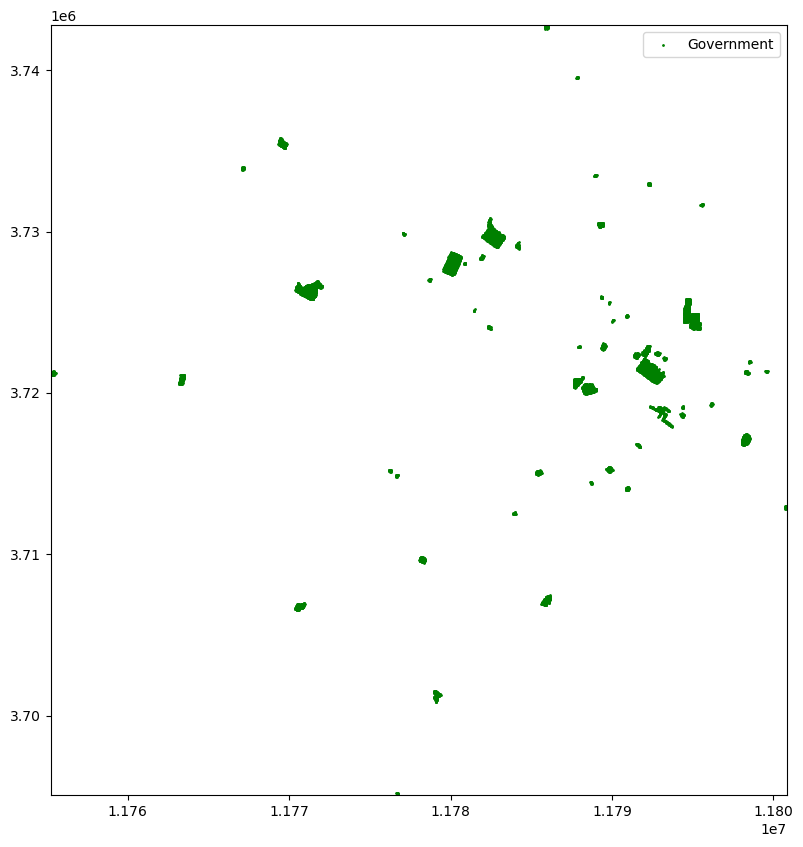

In [64]:
# Helper function to generate random points within a polygon
def generate_random_points_in_polygon(polygon, num_points):
    minx, miny, maxx, maxy = polygon.bounds
    points = []
    while len(points) < num_points:
        random_point = Point(np.random.uniform(minx, maxx), np.random.uniform(miny, maxy))
        if polygon.contains(random_point):
            points.append(random_point)
    return points

# Generate random points for each GeoDataFrame (dot density)
def generate_dot_density(gdf, density=1):
    dots = []
    for _, row in gdf.iterrows():
        num_points = int(row['geometry'].area * density)  # Density is proportional to polygon area
        points_in_polygon = generate_random_points_in_polygon(row['geometry'], num_points)
        dots.extend(points_in_polygon)
    return gpd.GeoDataFrame(geometry=gpd.GeoSeries(dots))

# Generate dot density for each layer
density = 0.001  # Adjust this value to control the number of dots based on area
#commercial_dots = generate_dot_density(Commercial_gdf, density)
government_dots = generate_dot_density(Government_gdf, density)
#industrial_dots = generate_dot_density(Industrial_gdf, density)
#institutional_dots = generate_dot_density(Institutional_gdf, density)
#mixed_dots = generate_dot_density(Mixed_gdf, density)
#office_dots = generate_dot_density(Office_gdf, density)

# Create the plot
fig, ax = plt.subplots(figsize=(10, 10))

# Plot each GeoDataFrame with a different color
#commercial_dots.plot(ax=ax, color='blue', markersize=1, label='Commercial')
government_dots.plot(ax=ax, color='green', markersize=1, label='Government')
#industrial_dots.plot(ax=ax, color='red', markersize=1, label='Industrial')
#institutional_dots.plot(ax=ax, color='purple', markersize=1, label='Institutional')
#mixed_dots.plot(ax=ax, color='orange', markersize=1, label='Mixed')
#office_dots.plot(ax=ax, color='brown', markersize=1, label='Office')

# Add a legend
plt.legend()

# Set axis limits (optional) based on the extent of the layers
ax.set_xlim(Government_gdf.total_bounds[[0, 2]])  # Setting x-axis bounds
ax.set_ylim(Government_gdf.total_bounds[[1, 3]])  # Setting y-axis bounds

# Display the plot
plt.show()
